# 📊 Otimizações e Análise Financeira em Julia
**Autor:** Pedro Victor Rodrigues Veras (PVRV / Batcaverna 2026)  
**Stack:** Julia (`Statistics`, `Plots`)  

Este notebook organiza e estrutura 3 cenários práticos de otimização e análise de dados:
1. **Análise de Consumo Mensal (2025 vs 2026)**
2. **Projeção de Receita SaaS (Projetos + Recorrência)**
3. **Evolução de Dívidas com Juros Compostos**

In [35]:
import Pkg; Pkg.add(["Plots", "DataFrames", "PlotlyJS"])

   Resolving package versions...
   Installed Hiccup ──────────────── v0.2.2
   Installed FunctionalCollections ─ v0.5.0
   Installed UnPack ──────────────── v1.0.2
   Installed Pidfile ─────────────── v1.3.0
   Installed Mustache ────────────── v1.0.21
   Installed URIs ────────────────── v1.7.0
   Installed Widgets ─────────────── v0.6.8
   Installed Mux ─────────────────── v1.0.2
   Installed Parsers ─────────────── v2.8.8
   Installed CodecZlib ───────────── v0.7.9
   Installed JSON ────────────────── v0.21.4
   Installed JSExpr ──────────────── v0.5.4
   Installed PlotlyKaleido ───────── v2.3.1
   Installed WebSockets ──────────── v1.6.0
   Installed PlotlyBase ──────────── v0.8.23
   Installed Lazy ────────────────── v0.15.1
   Installed Kaleido_jll ─────────── v0.2.1+0
   Installed AssetRegistry ───────── v0.1.1
   Installed Parameters ──────────── v0.12.3
   Installed PlotlyJS ────────────── v0.18.18
   Installed WebIO ───────────────── v0.8.21
   Installed Blink ──────────────

In [41]:
# Importação dos pacotes padrão para estatística, tabelas e gráficos
using Statistics
using DataFrames
using Plots
using PlotlyJS
gr() # Backend gráfico dos gráficos estáticos

Plots.GRBackend()

--- 
## 📈 Caso 1: Análise Estatística e Visualização de Consumo Mensal

Comparativo entre a segunda metade de 2025 (Julho a Dezembro) e o primeiro semestre de 2026 (Janeiro a Julho).

In [29]:
# 1. Definição dos vetores de consumo e meses
meses_2025 = ["Jul/25", "Ago/25", "Set/25", "Out/25", "Nov/25", "Dez/25"]
consumo_2025 = [326, 300, 336, 414, 427, 439]

meses_2026 = ["Jan/26", "Fev/26", "Mar/26", "Abr/26", "Mai/26", "Jun/26", "Jul/26"]
consumo_2026 = [540, 648, 761, 594, 548, 316, 319]

meses_2023 = ["Nov/22", "Dez/22", "Jan/23", "Fev/23", "Mar/23", "Abr/23", "Mai/23", "Jun/23", "Jul/23", "Ago/23", "Set/23", "Out/23", "Nov/23"]
consumo_2023 = [387, 409, 403, 648, 853, 567, 351, 339, 305, 289, 322, 424, 521]

function analisar_consumo(consumo_2023, consumo_2025, consumo_2026)
    resumo = DataFrame(
        :Indicador => ["Média (KWh)", "Total (KWh)", "Mínimo (KWh)", "Máximo (KWh)"],
        Symbol("2023") => [mean(consumo_2023), sum(consumo_2023), minimum(consumo_2023), maximum(consumo_2023)],
        Symbol("2025") => [mean(consumo_2025), sum(consumo_2025), minimum(consumo_2025), maximum(consumo_2025)],
        Symbol("2026") => [mean(consumo_2026), sum(consumo_2026), minimum(consumo_2026), maximum(consumo_2026)]
    )

    println("==============================================")
    println("ANÁLISE DE CONSUMO")
    println("==============================================")
    println("Menor consumo de 2023: ", minimum(consumo_2023), " KWh")
    println("Maior consumo de 2023: ", maximum(consumo_2023), " KWh")
    println("")
    println("Menor consumo de 2025: ", minimum(consumo_2025), " KWh")
    println("Maior consumo de 2025: ", maximum(consumo_2025), " KWh")
    println("")
    println("Menor consumo de 2026: ", minimum(consumo_2026), " KWh")
    println("Maior consumo de 2026: ", maximum(consumo_2026), " KWh")
    println("==============================================")

    return resumo
end

# O DataFrame final exibido no notebook
resumo_consumo = analisar_consumo(consumo_2023, consumo_2025, consumo_2026)
resumo_consumo

ANÁLISE DE CONSUMO
Menor consumo de 2023: 289 KWh
Maior consumo de 2023: 853 KWh

Menor consumo de 2025: 300 KWh
Maior consumo de 2025: 439 KWh

Menor consumo de 2026: 316 KWh
Maior consumo de 2026: 761 KWh


Row,Indicador,2023,2025,2026
,String,Float64,Float64,Float64
1,Média (KWh),447.538,373.667,532.286
2,Total (KWh),5818.0,2242.0,3726.0
3,Mínimo (KWh),289.0,300.0,316.0
4,Máximo (KWh),853.0,439.0,761.0


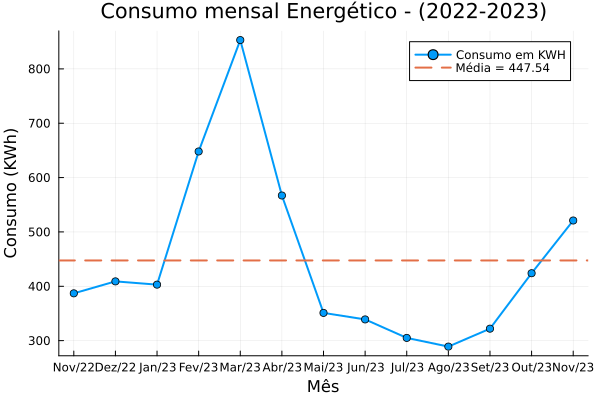

In [ ]:
# Visualização gráfica - Consumo 2023
function plot_consumo_2023(consumo, meses)
    media = mean(consumo)
    p = plot(
        1:length(consumo),
        consumo,
        marker=:circle,
        linewidth=2,
        xlabel="Mês",
        ylabel="Consumo (KWh)",
        title="Consumo mensal energético - 2022/2023",
        xticks=(1:length(meses), meses),
        label="Consumo em KWh"
    )
    hline!(p, [media], linestyle=:dash, linewidth=2, label="Média = $(round(media, digits=2))")
    savefig(p, "consumo_2023.png")
    return p
end

plot_consumo_2023(consumo_2023, meses_2023)

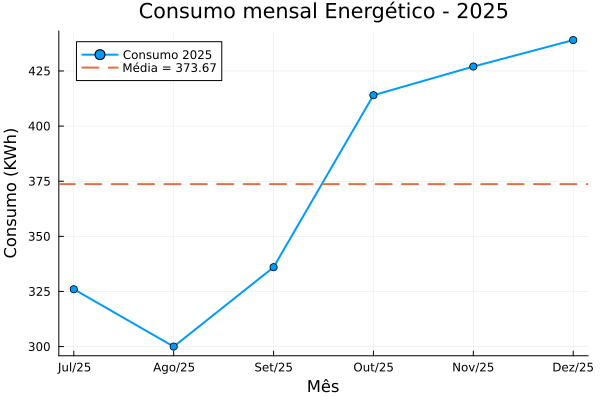

In [5]:
# Visualização gráfica - Consumo 2025
function plot_consumo_2025(consumo, meses)
    media = mean(consumo)
    p = plot(
        1:length(consumo),
        consumo,
        marker=:circle,
        linewidth=2,
        xlabel="Mês",
        ylabel="Consumo (KWh)",
        title="Consumo mensal Energético - 2025",
        xticks=(1:length(meses), meses),
        label="Consumo 2025"
    )
    hline!(p, [media], linestyle=:dash, linewidth=2, label="Média = $(round(media, digits=2))")
    # salva o gráfico em arquivo PNG
    savefig(p, "consumo_2025.png")
    return p
end

plot_consumo_2025(consumo_2025, meses_2025)

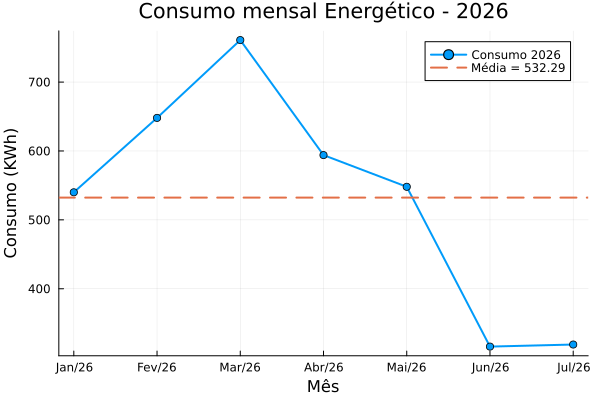

In [6]:
# Visualização gráfica - Consumo 2026
function plot_consumo_2026(consumo, meses)
    media = mean(consumo)
    p = plot(
        1:length(consumo),
        consumo,
        marker=:circle,
        linewidth=2,
        xlabel="Mês",
        ylabel="Consumo (KWh)",
        title="Consumo mensal Energético - 2026",
        xticks=(1:length(meses), meses),
        label="Consumo 2026"
    )
    hline!(p, [media], linestyle=:dash, linewidth=2, label="Média = $(round(media, digits=2))")
    
    # salva o gráfico em arquivo PNG
    savefig(p, "consumo_2026.png")
    return p
end

plot_consumo_2026(consumo_2026, meses_2026)



### Analise e projeção juntando os dados desde 2022 ate 2026 (ignorando 2024)

In [ ]:
# Análise e visualização conjunta: Nov/22 até Jul/26
# Os pontos são sequenciais para não criar gaps nos períodos sem dados.
# Uma linha preta contínua conecta todos os pontos, inclusive entre anos.

meses_2022 = ["Nov/22", "Dez/22"]
consumo_2022 = [387, 409]
posicoes_2022 = 1:2

meses_2023 = ["Jan/23", "Fev/23", "Mar/23", "Abr/23", "Mai/23", "Jun/23", "Jul/23", "Ago/23", "Set/23", "Out/23", "Nov/23"]
consumo_2023 = [403, 648, 853, 567, 351, 339, 305, 289, 322, 424, 521]
posicoes_2023 = 3:13

meses_2025 = ["Jul/25", "Ago/25", "Set/25", "Out/25", "Nov/25", "Dez/25"]
consumo_2025 = [326, 300, 336, 414, 427, 439]
posicoes_2025 = 14:19

meses_2026 = ["Jan/26", "Fev/26", "Mar/26", "Abr/26", "Mai/26", "Jun/26", "Jul/26"]
consumo_2026 = [540, 648, 761, 594, 548, 316, 319]
posicoes_2026 = 20:26

meses_completos = vcat(meses_2022, meses_2023, meses_2025, meses_2026)
consumo_completo = vcat(consumo_2022, consumo_2023, consumo_2025, consumo_2026)
posicoes_completas = 1:length(meses_completos)

function marcar_min_max!(grafico, posicoes, consumo, ano)
    indice_min = argmin(consumo)
    indice_max = argmax(consumo)

    scatter!(grafico, [posicoes[indice_min]], [consumo[indice_min]], color=:green, markersize=8, markerstrokecolor=:white, label="Mínimo $(ano)")
    scatter!(grafico, [posicoes[indice_max]], [consumo[indice_max]], color=:red, markersize=8, markerstrokecolor=:white, label="Máximo $(ano)")
end

function plot_consumo_completo()
    grafico = plot(
        posicoes_2022,
        consumo_2022,
        linecolor=:black,
        markercolor=:purple,
        marker=:circle,
        linewidth=2,
        xlabel="Mês",
        ylabel="Consumo (KWh)",
        title="Consumo energético: Nov/22 a Jul/26",
        label="2022",
        legend=:outertopright,
        size=(1200, 650),
        xrotation=45,
        xticks=(posicoes_completas, meses_completos),
        margin=5Plots.mm
    )

    plot!(grafico, posicoes_2023, consumo_2023, linecolor=:black, markercolor=:blue, marker=:circle, linewidth=3, label="2023")
    plot!(grafico, posicoes_2025, consumo_2025, linecolor=:black, markercolor=:orange, marker=:circle, linewidth=3, label="2025")
    plot!(grafico, posicoes_2026, consumo_2026, linecolor=:black, markercolor=:teal, marker=:circle, linewidth=3, label="2026")

    # Linha preta única ligando todos os pontos, inclusive as transições entre anos.
    plot!(grafico, posicoes_completas, consumo_completo, linecolor=:black, linewidth=2, marker=false, label="Linha contínua")

    marcar_min_max!(grafico, posicoes_2022, consumo_2022, 2022)
    marcar_min_max!(grafico, posicoes_2023, consumo_2023, 2023)
    marcar_min_max!(grafico, posicoes_2025, consumo_2025, 2025)
    marcar_min_max!(grafico, posicoes_2026, consumo_2026, 2026)

    savefig(grafico, "consumo_em_serie_temporal.png")
    return grafico
end

plot_consumo_completo()

UndefVarError: UndefVarError: `attr` not defined in `PlotlyJS`
Suggestion: check for spelling errors or missing imports.

--- 
## 💼 Caso 2: Modelo de Projeção de Receita SaaS (Projetos + Recorrência)

Cálculo de modelo de negócios com venda de projetos de software e recorrência de manutenção mensal.

In [7]:
function calcular_saas(quantidade_vendas, valor_projeto, manutencao_mensal, meses_manutencao)
    receita_projetos = quantidade_vendas * valor_projeto
    receita_manutencao_mensal = quantidade_vendas * manutencao_mensal
    receita_manutencao_total = receita_manutencao_mensal * meses_manutencao
    receita_total = receita_projetos + receita_manutencao_total
    media_mensal = receita_total / meses_manutencao
    
    println("==============================================")
    println("💼 ANÁLISE DE MODELO SAAS")
    println("==============================================")
    println("Receita dos projetos: R\$ ", round(receita_projetos, digits=2))
    println("Manutenção mensal: R\$ ", round(receita_manutencao_mensal, digits=2))
    println("Manutenção em 6 meses: R\$ ", round(receita_manutencao_total, digits=2))
    println("Receita total: R\$ ", round(receita_total, digits=2))
    println("Média mensal em 6 meses: R\$ ", round(media_mensal, digits=2))
    println()
    return receita_total, media_mensal
end

# Execução do modelo SaaS
qtd_vendas = 2000
vlr_projeto = 3000.0
mnt_mensal = 50.0
meses_mnt = 6

rec_tot, med_mensal = calcular_saas(qtd_vendas, vlr_projeto, mnt_mensal, meses_mnt);

💼 ANÁLISE DE MODELO SAAS
Receita dos projetos: R$ 6.0e6
Manutenção mensal: R$ 100000.0
Manutenção em 6 meses: R$ 600000.0
Receita total: R$ 6.6e6
Média mensal em 6 meses: R$ 1.1e6



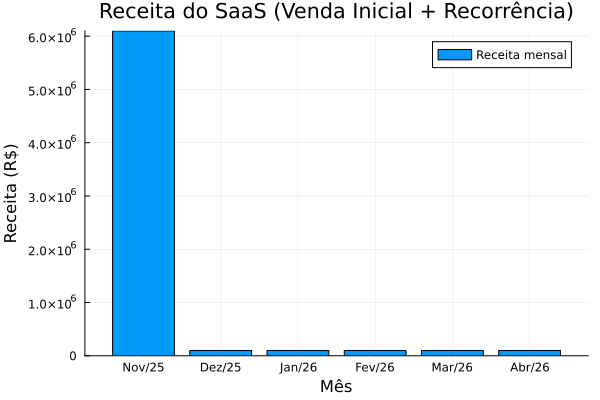

In [8]:
# Gráfico de Barras - Fluxo de Caixa Mensal do SaaS
function plot_saas(quantidade_vendas, valor_projeto, manutencao_mensal, meses_manutencao)
    receita_inicial = quantidade_vendas * valor_projeto
    receita_manutencao = quantidade_vendas * manutencao_mensal
    receita_mensal = zeros(meses_manutencao)
    
    # Novembro = Venda inicial + primeira manutenção
    receita_mensal[1] = receita_inicial + receita_manutencao
    for i in 2:meses_manutencao
        receita_mensal[i] = receita_manutencao
    end
    
    meses = ["Nov/25", "Dez/25", "Jan/26", "Fev/26", "Mar/26", "Abr/26"]
    
    p = bar(
        meses,
        receita_mensal,
        xlabel="Mês",
        ylabel="Receita (R\$)",
        title="Receita do SaaS (Venda Inicial + Recorrência)",
        label="Receita mensal",
        legend=:topright
    )
    return p
end

plot_saas(qtd_vendas, vlr_projeto, mnt_mensal, meses_mnt)

--- 
## 🏦 Caso 3: Simulação Financeira de Dívidas e Juros Compostos

Evolução temporal de saldo devedor sob taxas de juros anuais compostas.

In [9]:
function calcular_divida(divida_inicial, taxa_anual)
    juros_anuais = divida_inicial * taxa_anual
    divida_apos_1_ano = divida_inicial + juros_anuais
    
    println("==============================================")
    println("🏛️ ANÁLISE DE DÍVIDA E JUROS COMPOSTOS")
    println("==============================================")
    println("Dívida inicial: R\$ ", round(divida_inicial, digits=2))
    println("Taxa anual: ", taxa_anual * 100, "%")
    println("Juros em 1 ano: R\$ ", round(juros_anuais, digits=2))
    println("Dívida após 1 ano: R\$ ", round(divida_apos_1_ano, digits=2))
    println()
    return juros_anuais, divida_apos_1_ano
end

divida_ini = 13_000_000_000.0 # 13 bilhões
taxa_ano = 0.14               # 14% a.a.

calcular_divida(divida_ini, taxa_ano);

🏛️ ANÁLISE DE DÍVIDA E JUROS COMPOSTOS
Dívida inicial: R$ 1.3e10
Taxa anual: 14.000000000000002%
Juros em 1 ano: R$ 1.82e9
Dívida após 1 ano: R$ 1.482e10



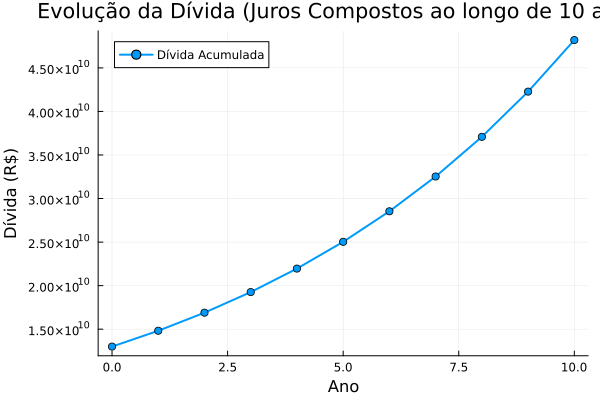

In [10]:
# Visualização da Evolução Decenal da Dívida
function plot_divida(divida_inicial, taxa_anual, numero_anos)
    anos = 0:numero_anos
    divida = [divida_inicial * (1 + taxa_anual)^ano for ano in anos]
    
    p = plot(
        anos,
        divida,
        marker=:circle,
        linewidth=2,
        xlabel="Ano",
        ylabel="Dívida (R\$)",
        title="Evolução da Dívida (Juros Compostos ao longo de $(numero_anos) anos)",
        label="Dívida Acumulada"
    )
    return p
end

plot_divida(divida_ini, taxa_ano, 10)